<a href="https://colab.research.google.com/github/rimfa/shopee-product-matching/blob/main/notebooks/baseline.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Shopee Product Matching: TF-IDF + pHash baseline

Baseline for product matching using two lightweight signals:
- title similarity with TF-IDF;
- image similarity with perceptual hashes (pHash).

The goal is to combine both candidate sets and tune matching thresholds using local validation.

In [6]:
import pandas as pd
from PIL import Image
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import cv2
import math
import tensorflow as tf
import sys
import gc
import math
from tqdm import tqdm

In [7]:
train_df_path = os.path.join(path, "train.csv")
train_df = pd.read_csv(train_df_path)

In [8]:
train_df.head()

,posting_id,image,image_phash,title,label_group
0,train_129225211,0000a68812bc7e98c42888dfb1c07da0.jpg,94974f937d4c2433,Paper Bag Victoria Secret,249114794
1,train_3386243561,00039780dfc94d01db8676fe789ecd05.jpg,af3f9460c2838f0f,"Double Tape 3M VHB 12 mm x 4,5 m ORIGINAL / DO...",2937985045
2,train_2288590299,000a190fdd715a2a36faed16e2c65df7.jpg,b94cb00ed3e50f78,Maling TTS Canned Pork Luncheon Meat 397 gr,2395904891
3,train_2406599165,00117e4fc239b1b641ff08340b429633.jpg,8514fc58eafea283,Daster Batik Lengan pendek - Motif Acak / Camp...,4093212188
4,train_3369186413,00136d1cf4edede0203f32f05f660588.jpg,a6f319f924ad708c,Nescafe \xc3\x89clair Latte 220ml,3648931069


In [34]:
train_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 34250 entries, 0 to 34249
Data columns (total 8 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   posting_id      34250 non-null  object 
 1   image           34250 non-null  object 
 2   image_phash     34250 non-null  object 
 3   title           34250 non-null  object 
 4   label_group     34250 non-null  int64  
 5   pred_matches    34250 non-null  object 
 6   target_matches  34250 non-null  object 
 7   f1_score        34250 non-null  float64
dtypes: float64(1), int64(1), object(6)
memory usage: 2.1+ MB


In [10]:
train_df.shape

(34250, 5)

In [11]:
train_images_path = os.path.join(path, "train_images")
train_images = os.listdir(train_images_path)

In [12]:
train_images[:10]

['2e7e0048551bf27296190ea3490945cd.jpg',
 'd80e2f718ea6d7769d1f77ec20a70b37.jpg',
 'd53f5dad1ba27e7d8ad1f1f2093e3d29.jpg',
 '5a5b56405b4aca7c640b84a946a95077.jpg',
 '6b4e274bd161e97237a499385567ef3a.jpg',
 '8d9f67d5dc04cef8c52a15c8fb0993d6.jpg',
 '035ae4427ce419f5692ab241310100db.jpg',
 '42eb5192d8936e65d56a044796d5473f.jpg',
 '818882b8920f6e4f881dc7def2e890f5.jpg',
 '58442403e69c39eef652dbb710f86a37.jpg']

Check the available training images and inspect a sample image.

(800, 800)


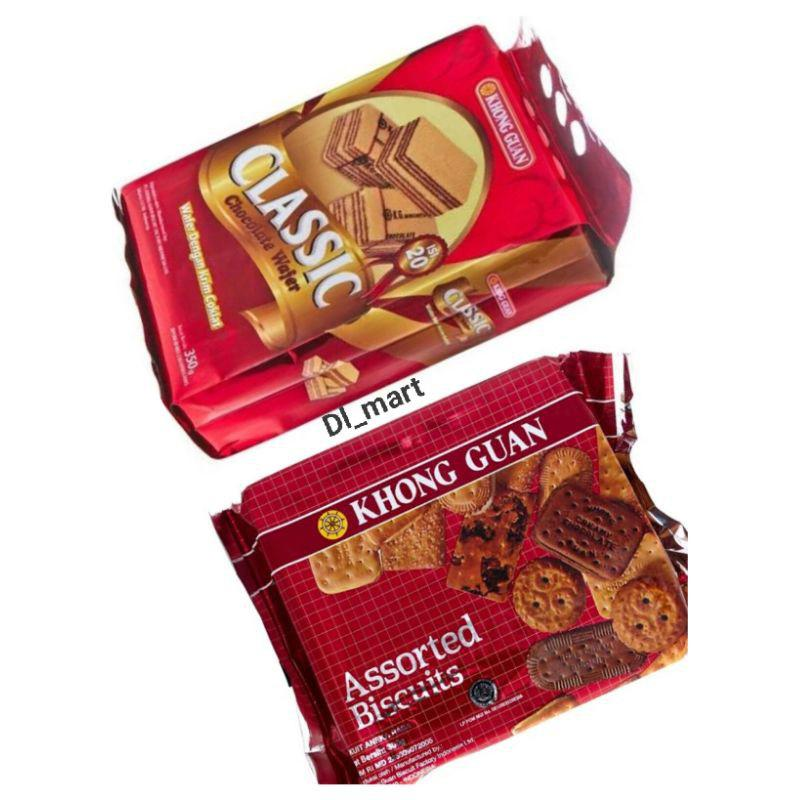

In [14]:
img = Image.open(os.path.join(train_images_path, train_images[2]))
print(img.size)
img

In [15]:
group_sizes = train_df.groupby("label_group").size().sort_values(ascending=False).rename("group_size").reset_index()
group_size_counts = group_sizes.groupby("group_size").size().rename("count_of_group").sort_values(ascending=False).reset_index()
group_size_counts.head()

,group_size,count_of_group
0,2,6979
1,3,1779
2,4,862
3,5,468
4,6,282


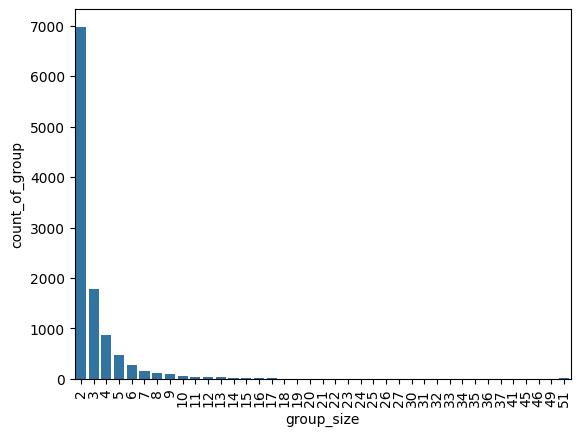

In [20]:
sns.barplot(
    x=group_size_counts['group_size'],
    y=group_size_counts['count_of_group']
)

plt.xticks(rotation=90)
plt.show()

In [21]:
same_hash = train_df.groupby("image_phash").size().sort_values(ascending=False).rename("count").reset_index()
same_hash = same_hash[same_hash["count"] > 1]
same_hash.head(3)

,image_phash,count
0,fad28daa2ad05595,26
1,d0c0ea37bd9acce0,20
2,be12e12f9ec1e198,17


In [22]:
len(same_hash)

3229

Compare listings that share the same perceptual hash.

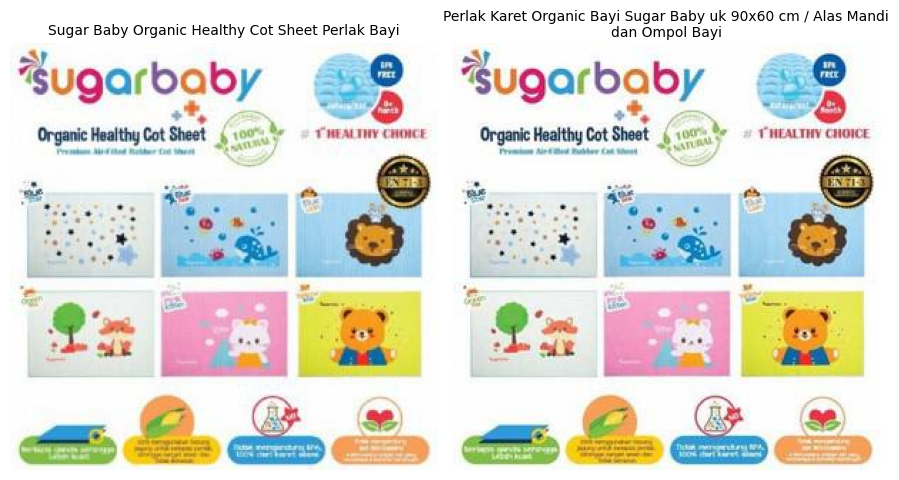

In [23]:
target_phash = "fad28daa2ad05595"

matches = train_df[train_df["image_phash"] == target_phash].head(2)

fig, axes = plt.subplots(1, 2, figsize=(9, 6))
for ax, (_, row) in zip(axes, matches.iterrows()):
    img = Image.open(os.path.join(train_images_path, row["image"]))
    ax.imshow(img)
    ax.axis('off')
    ax.set_title(row["title"], fontsize=10, wrap=True)

plt.tight_layout()
plt.show()

In [25]:
matches = train_df.groupby("image_phash")["posting_id"].apply(list)
train_df["pred_matches"] = train_df["image_phash"].map(matches)

target_matches = train_df.groupby('label_group')['posting_id'].apply(list)
train_df['target_matches'] = train_df['label_group'].map(target_matches)

Listings with the same perceptual hash are treated as product matches.

In [26]:
train_df.head(2)

,posting_id,image,image_phash,title,label_group,pred_matches,target_matches
0,train_129225211,0000a68812bc7e98c42888dfb1c07da0.jpg,94974f937d4c2433,Paper Bag Victoria Secret,249114794,[train_129225211],"[train_129225211, train_2278313361]"
1,train_3386243561,00039780dfc94d01db8676fe789ecd05.jpg,af3f9460c2838f0f,"Double Tape 3M VHB 12 mm x 4,5 m ORIGINAL / DO...",2937985045,[train_3386243561],"[train_3386243561, train_3423213080]"


In [27]:
def calculate_f1(target, preds):
  target_matches=set(target)
  pred_matches=set(preds)

  common = (target_matches & pred_matches)
  if len(common) == 0:
    return 0
  precision = len(common) / len(pred_matches)
  recall = len(common) / len(target_matches)

  f1 = 2 * (precision * recall) / (precision + recall)
  return f1


In [28]:
train_df['f1_score'] = train_df.apply(lambda row: calculate_f1(row['target_matches'], row['pred_matches']),axis=1)
final_score = train_df['f1_score'].mean()
print(f"Базовый F1-score по phash: {final_score:.4f}")

Базовый F1-score по phash: 0.5531


Listings of the same product can use visually different images, so requiring identical pHash values misses valid matches.

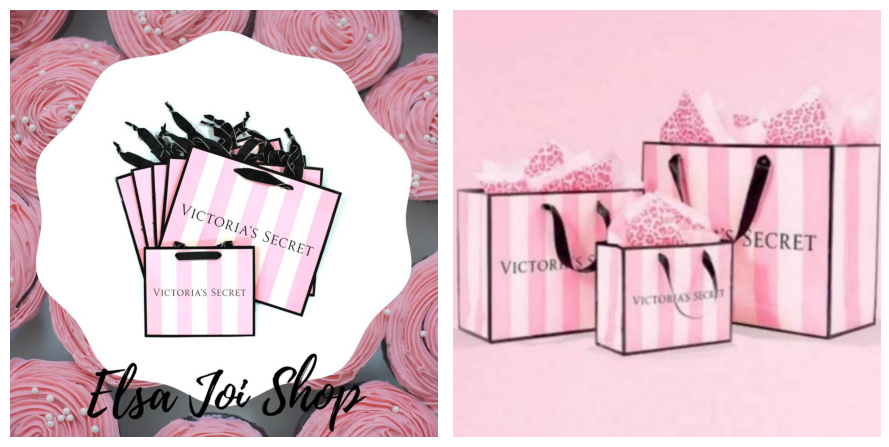

In [29]:
im1 = train_df[train_df['posting_id'] == 'train_129225211']['image'].reset_index(drop=True).loc[0]
im2 = train_df[train_df['posting_id'] == 'train_2278313361']['image'].reset_index(drop=True).loc[0]
imgs = [im1, im2]
fig, axes = plt.subplots(1, 2, figsize=(9, 6))
for ax, im in zip(axes,imgs):
    img = Image.open(os.path.join(train_images_path, im))
    ax.imshow(img)
    ax.axis('off')

plt.tight_layout()
plt.show()

Instead of requiring identical hashes, compare pHash values by Hamming distance.

In [35]:
def hex_to_bits(phash):
    binary = format(int(phash, 16), '064b')
    return [int(bit) for bit in binary]

hashes = train_df['image_phash']

X_hashes = np.array([hex_to_bits(h) for h in hashes])
X_hashes.shape

(34250, 64)

In [36]:
len(X_hashes[0])

64

Search for visually similar images by allowing a small Hamming distance between perceptual hashes.

Allowing small differences between pHash values improves matching quality.  
The best score is reached around 8–9 different bits, while larger thresholds begin to introduce false matches.

In [37]:
from sklearn.neighbors import NearestNeighbors

max_bits = 12
post_ids = train_df['posting_id'].values

nn = NearestNeighbors(metric='hamming')
nn.fit(X_hashes)

distances, indices = nn.radius_neighbors(X_hashes, radius=max_bits / 64)

f1_scores = []

for bits in range(max_bits + 1):
    radius = bits / 64
    pred_matches = []

    for idx, (dist, idxs) in enumerate(zip(distances, indices)):
        i = idxs[dist <= radius]
        matches_array = post_ids[i]

        matches_set = set(matches_array)
        matches_set.add(post_ids[idx])

        pred_matches.append(matches_set)

    train_df['pred_matches'] = pred_matches

    scores_series = train_df.apply(lambda row: calculate_f1(row['target_matches'],row['pred_matches']),axis=1)
    mean_score = scores_series.mean()
    f1_scores.append(mean_score)

In [39]:
for bits, score in enumerate(f1_scores):
    print(f"Bits: {bits} | Mean F1: {score:.4f}")

Bits: 0 | Mean F1: 0.5531
Bits: 1 | Mean F1: 0.5531
Bits: 2 | Mean F1: 0.5760
Bits: 3 | Mean F1: 0.5760
Bits: 4 | Mean F1: 0.5866
Bits: 5 | Mean F1: 0.5866
Bits: 6 | Mean F1: 0.5940
Bits: 7 | Mean F1: 0.5940
Bits: 8 | Mean F1: 0.5956
Bits: 9 | Mean F1: 0.5956
Bits: 10 | Mean F1: 0.5847
Bits: 11 | Mean F1: 0.5847
Bits: 12 | Mean F1: 0.5311


Product titles are cleaned and represented with TF-IDF using word unigrams and bigrams.

In [38]:
import re
from sklearn.feature_extraction.text import TfidfVectorizer
def clean_text(string):
    string = re.sub(r'[^а-яА-ЯёЁa-zA-Z0-9]', ' ', string)
    string = re.sub(r'\s+', ' ', string)
    return string.strip()

post_ids = train_df['posting_id'].values

corpus = train_df['title'].apply(clean_text)
vectorizer = TfidfVectorizer(analyzer='word', ngram_range=(1, 2), max_features=27000)
X_tfidf = vectorizer.fit_transform(corpus)

In [40]:
knn = NearestNeighbors(metric='cosine')
knn.fit(X_tfidf)

distances, indices = knn.kneighbors(X_tfidf, n_neighbors=50)
f1_scores = []

for threshold in np.arange(0.1, 0.75, 0.05):
    pred_matches = []

    for idx, (dist, idxs) in enumerate(zip(distances, indices)):
        matches_id = idxs[dist <= threshold]  # Массив ИНДЕКСОВ (номера строк): [0, 2]
        matches_array = post_ids[matches_id]  # Массив СТРОКОВЫХ ID: ['train_11', 'train_33']
        matches_set = set(matches_array)      # МНОЖЕСТВО строковых ID: {'train_11', 'train_33'}
        matches_set.add(post_ids[idx])        # SELF-MATCH (добавили ID самого товара): {'train_11', 'train_33'}
        pred_matches.append(matches_set)      # Накопление: добавили готовый сет в общий список

    train_df['pred_matches'] = pred_matches

    scores_series = train_df.apply(
        lambda row: calculate_f1(
            row['target_matches'],
            row['pred_matches']
        ),
        axis=1
    )

    mean_score = scores_series.mean()
    f1_scores.append(mean_score)

    print(f"Threshold: {threshold:.2f} | Mean F1: {mean_score:.4f}")

    train_df.drop(columns=['pred_matches'], inplace=True)

Threshold: 0.10 | Mean F1: 0.5243
Threshold: 0.15 | Mean F1: 0.5446
Threshold: 0.20 | Mean F1: 0.5648
Threshold: 0.25 | Mean F1: 0.5834
Threshold: 0.30 | Mean F1: 0.6004
Threshold: 0.35 | Mean F1: 0.6137
Threshold: 0.40 | Mean F1: 0.6229
Threshold: 0.45 | Mean F1: 0.6236
Threshold: 0.50 | Mean F1: 0.6128
Threshold: 0.55 | Mean F1: 0.5909
Threshold: 0.60 | Mean F1: 0.5526
Threshold: 0.65 | Mean F1: 0.4981
Threshold: 0.70 | Mean F1: 0.4312


In [41]:
train_df['label_group'].unique()

array([ 249114794, 2937985045, 2395904891, ..., 1313560418,  763032672,
         53836859])

Split by `label_group` so that listings from the same product group stay in the same subset.

In [42]:
from sklearn.model_selection import train_test_split

group_id = train_df['label_group'].unique()

x_train_idx, x_val_idx = train_test_split(group_id,test_size=0.2,random_state=101)

train = train_df[train_df.label_group.isin(x_train_idx)]
val = train_df[train_df.label_group.isin(x_val_idx)]

train_hashes = X_hashes[train.index]
val_hashes = X_hashes[val.index]

train_tfidf = X_tfidf[train.index]
val_tfidf = X_tfidf[val.index]

In [43]:
i = [0, 1, 2]
train.target_matches[i].values

array([list(['train_129225211', 'train_2278313361']),
       list(['train_3386243561', 'train_3423213080']),
       list(['train_2288590299', 'train_3803689425'])], dtype=object)

Combine TF-IDF and pHash matches using a union of both candidate sets.  
Thresholds are selected on validation queries while neighbors are searched against the full gallery.

In [44]:
from sklearn.neighbors import NearestNeighbors

def multimodal(val_data, val_hash, val_tfidf, global_hash, global_tfidf, global_df):
    res = []

    global_post_ids = global_df['posting_id'].values
    max_bits = 9

    hash_knn = NearestNeighbors(metric='hamming')
    hash_knn.fit(global_hash)
    hash_dist, hash_idxs = hash_knn.radius_neighbors(val_hash, radius=max_bits/64)

    tfidf_knn = NearestNeighbors(metric='cosine')
    tfidf_knn.fit(global_tfidf)
    tfidf_dist, tfidf_idxs = tfidf_knn.kneighbors(val_tfidf, n_neighbors=50)

    thresholds = np.arange(0.1, 0.75, 0.05)

    for bit in range(4, max_bits+1):
        for t in thresholds:
            f1_scores = []

            for i in range(len(val_data)):
                h_ind = hash_idxs[i][hash_dist[i] <= bit/64]
                img_neighb = global_post_ids[h_ind]

                tfidf_ind = tfidf_idxs[i][tfidf_dist[i] <= t]
                txt_neighb = global_post_ids[tfidf_ind]

                preds = set(txt_neighb) | set(img_neighb)
                f1_scores.append(calculate_f1(val_data['target_matches'].iloc[i], preds))

            mean_f1 = np.mean(f1_scores)
            res.append([bit, round(t, 4), round(mean_f1, 4)])

    return res

In [45]:
res = multimodal(val_data=val, val_hash=val_hashes, val_tfidf=val_tfidf, global_hash=X_hashes,
                 global_tfidf=X_tfidf,
                 global_df=train_df)
res = pd.DataFrame(res, columns=['bit', 'threshold', 'f1']).sort_values(by='f1', ascending=False)

In [46]:
res.head()

,bit,threshold,f1
32,6,0.40,0.6955
45,7,0.40,0.6955
44,7,0.35,0.6949
31,6,0.35,0.6949
58,8,0.40,0.6926
